In [1]:
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import yfinance as yf

Hey guys, so this group I know here is trying to sell this to Jamaica.
Here's an updated version. 
- Nathan 
- Gentill 
- Zach Milam 
- Chris [after]
Development 
- Matthew Lee
- Cameron Rozean
- Ross Tagaras [later]

This code is unoptimised

(Multi time correlation function)

Definitions:
- Lookback: Time factor in business days
- Mean: Mean of internalised rates of return (IRR) or correlation ($\rho$)
- Median: Median of internalised rates of return (IRR) or correlation ($\rho$)

Strategy:
- Follow the lookback's correlation, keeping the window of days smaller than the spread or lookback.

Adjustments:
- Include shorting stocks by uncommenting the lines about if "sign > 0"
- Adding options strategy



In [2]:
symbols = [
    # "^DJI",
    # "^GSPC"
    "AMD",
    "MU",
]

START = "2015-01-01"
END = None

signal = yf.download(symbols, start=START, end=END)["Close"].dropna()

AMD = signal[symbols[0]]

MU = signal[symbols[-1]]


def correlation(m, n):
    return np.corrcoef(m, n)[0][1]

/var/folders/mq/f_2xhb9d4xv13xb4888zcc_80000gn/T/ipykernel_4495/342734477.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  signal = yf.download(symbols, start=START, end=END)["Close"].dropna()
[*********************100%***********************]  2 of 2 completed


In [3]:
signal

Ticker,AMD,MU
Date,,
2015-01-02,2.670000,33.919151
2015-01-05,2.660000,32.972359
2015-01-06,2.630000,32.084110
2015-01-07,2.580000,31.332521
2015-01-08,2.610000,32.864983
...,...,...
2025-11-17,240.520004,241.949997
2025-11-18,230.289993,228.500000
2025-11-19,223.550003,225.919998


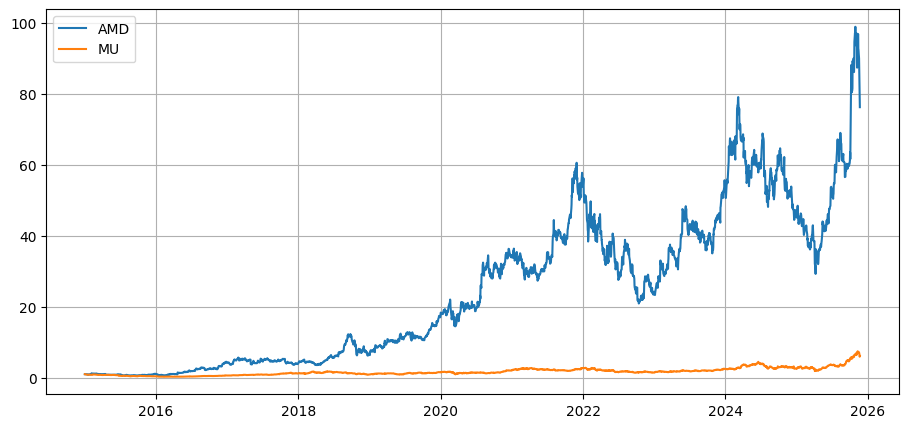

In [4]:
plt.figure(figsize=(11, 5))
plt.plot(signal / signal.iloc[0], label=signal.columns)
plt.legend()
plt.grid()
plt.show()

In [5]:
M = 24

CDS = dict(zip(range(1, M + 1), [None] * (M + 1)))
CSD = dict(zip(range(1, M + 1), [None] * (M + 1)))

PSD = CSD.copy()
PDS = CDS.copy()

initial = 9 * signal.shape[0] // 10

for m in CSD.keys():
    l = 0
    spread_days = np.linspace(2 * m, 2 * (m + 1), 3).astype(int)
    window_days = spread_days.copy()

    # window_days = (spread_days.copy() ** 0.5).astype(int)

    CDS[m] = []
    CSD[m] = []

    PDS[m] = []
    PSD[m] = []

    for i in range(initial, signal.shape[0]):
        # faster to calculate all in advance or use multiprocessing et cetera
        # this was a step taken from another version
        for spread in spread_days:
            if 2 * (i + spread) >= AMD.shape[0] + MU.shape[0]:
                break

            for w in window_days:
                x, y, q, z = (
                    np.array(AMD.iloc[i : i + w]),
                    np.array(MU.iloc[i : i + w]),
                    np.array(AMD.iloc[i + spread : i + spread + w]),
                    np.array(MU.iloc[i + spread : i + spread + w]),
                )

                if w > spread:
                    break

                if len(x) + len(y) + len(z) + len(q) != 4 * w:
                    break

                c_ = correlation(x, z)
                CDS[m].append(c_)

                sign = np.sign(x[-1] / x[0] - 1)
                # if spread > 100:
                # sign *= -1 # depends on time

                p_ = (1 + (z[-1] / z[0] - 1) * sign) ** (250 / w) - 1
                if not np.isnan(p_) and sign > 0:
                    PDS[m].append(100*p_)

                c_ = correlation(y, q)
                CSD[m].append(c_)

                sign = np.sign(y[-1] / y[0] - 1)
                # if spread > 70:
                #   sign *= -1

                p_ = (1 + (q[-1] / q[0] - 1) * sign) ** (250 / w) - 1
                if not np.isnan(p_) and sign > 0:
                    PSD[m].append(100*p_)

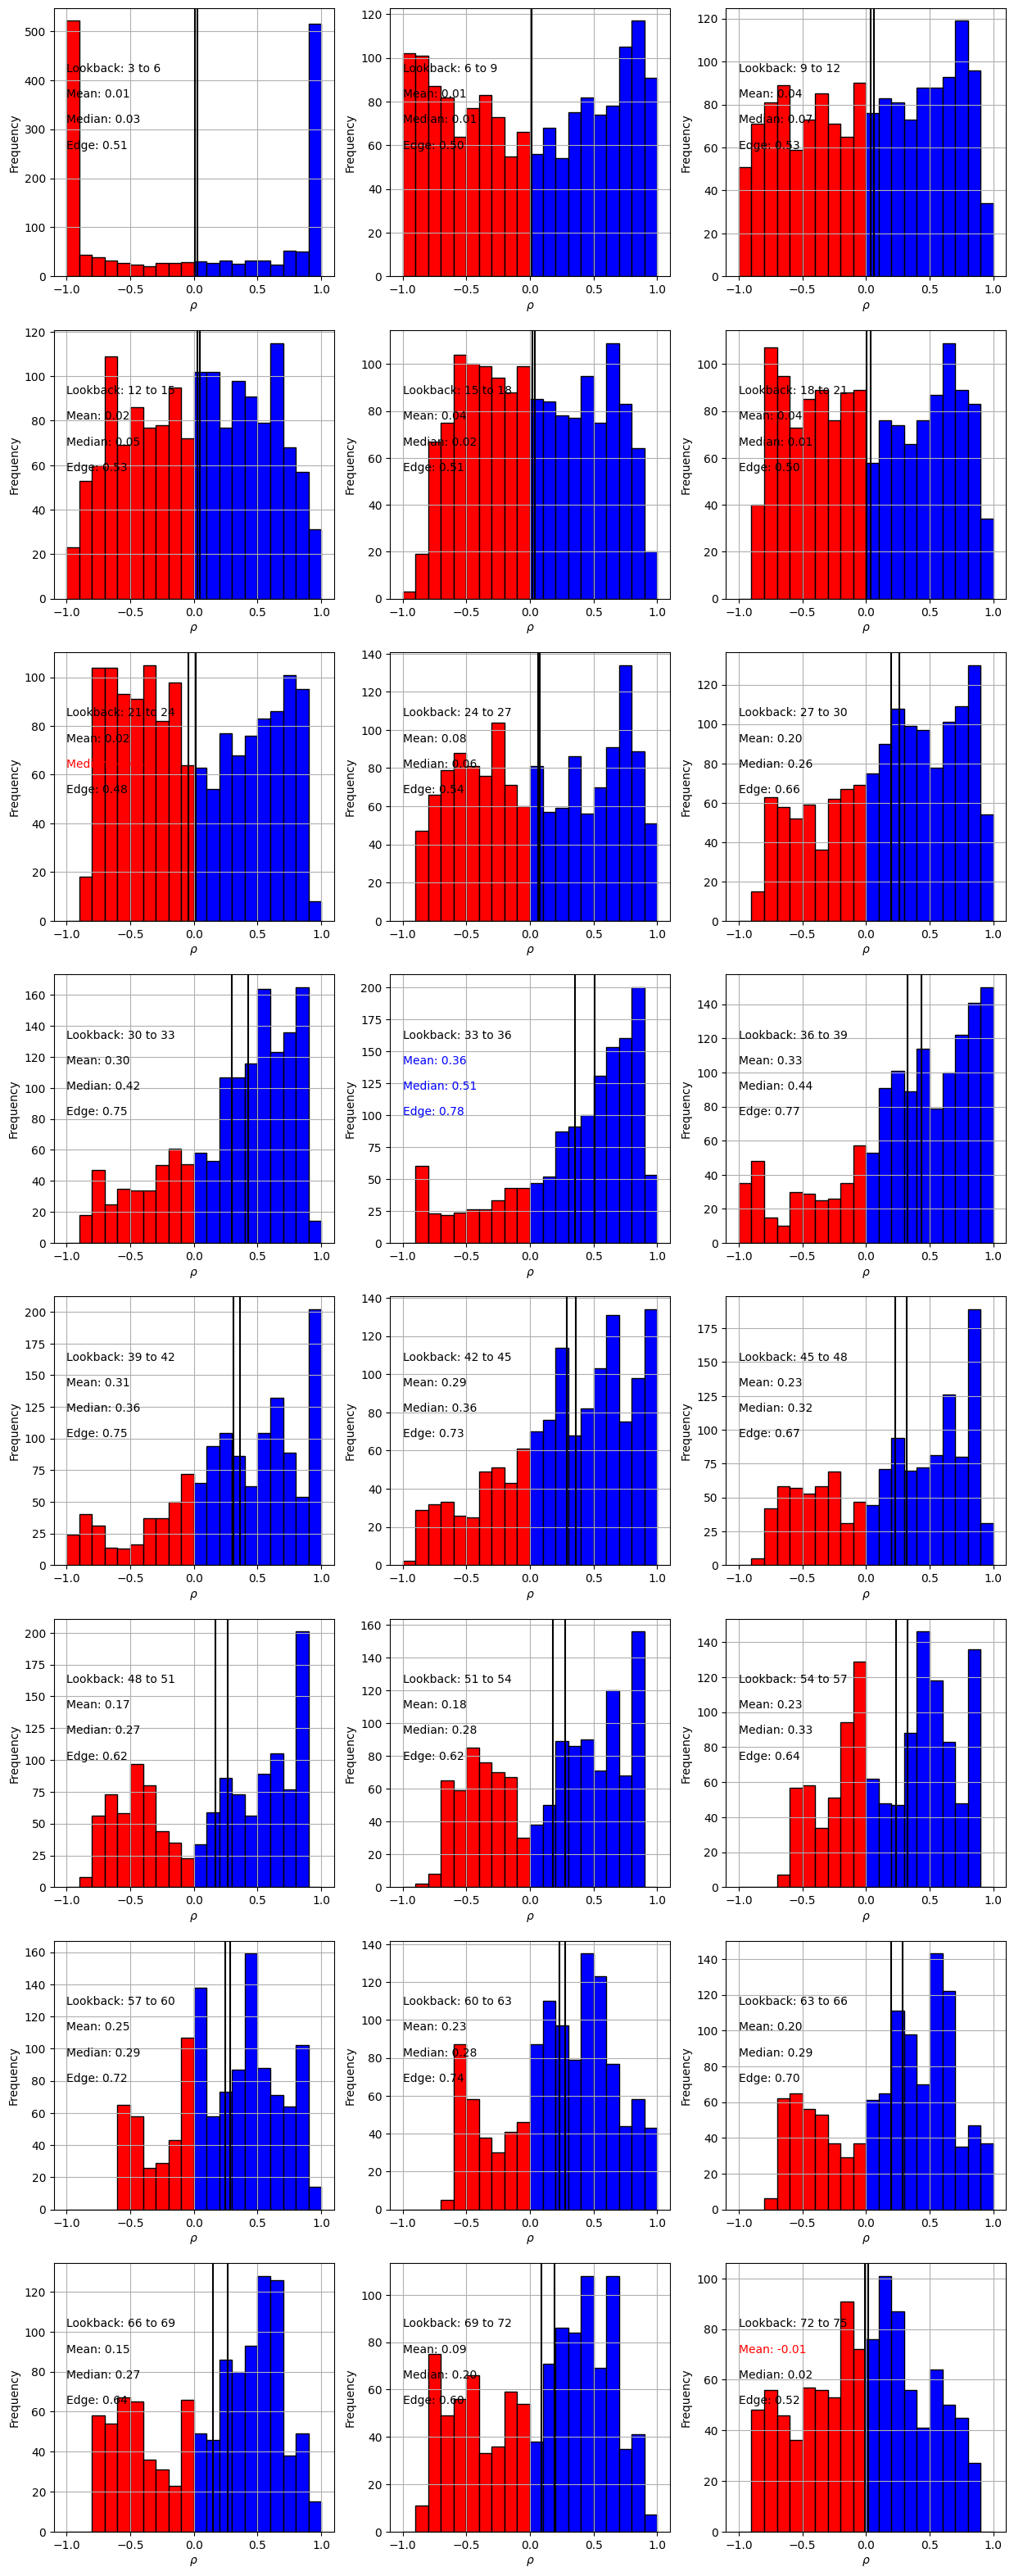

In [6]:
fig, axes = plt.subplots(8, 3, figsize=(15, 40))
medians = [np.median(CSD[k]) for k in CSD]
means = [np.mean(CSD[k]) for k in CSD]
edges = [(np.array(CSD[k]) > 0).sum() / len(CSD[k]) for k in CSD]
edge_min, edge_max = np.max(edges), np.max(edges)
median_min, median_max = np.min(medians), np.max(medians)
mean_min, mean_max = np.min(means), np.max(means)
for i in range(8):
    for j in range(3):
        k = i * 3 + j + 1
        # bins = np.linspace(0, min(10, np.max(C[k])), 11)
        bins = np.linspace(-1, 1, 21)
        x, y, z = axes[i][j].hist(CSD[k], bins=bins, edgecolor="black")
        for l in range(len(z)):
            if l < len(z) // 2:
                z[l].set_facecolor("r")
            else:
                z[l].set_facecolor("b")

        c_mean = (
            "b"
            if means[k - 1] == mean_max
            else ("r" if means[k - 1] == mean_min else "k")
        )
        c_median = (
            "b"
            if medians[k - 1] == median_max
            else ("r" if medians[k - 1] == median_min else "k")
        )
        c_edge = (
            "b"
            if edges[k - 1] == edge_max
            else ("r" if edges[k - 1] == edge_min else "k")
        )

        axes[i][j].axvline(np.median(CSD[k]), color="k")
        axes[i][j].axvline(np.mean(CSD[k]), color="k")
        axes[i][j].text(bins[0], 0.8 * x.max(), f"Lookback: {3 * k} to {3 * (k + 1)}")
        axes[i][j].text(
            bins[0], 0.5 * x.max(), f"Edge: {edges[k - 1]:.2f}", color=c_edge
        )
        axes[i][j].text(
            bins[0], 0.7 * x.max(), f"Mean: {means[k - 1]:.2f}", color=c_mean
        )
        axes[i][j].text(
            bins[0], 0.6 * x.max(), f"Median: {medians[k - 1]:.2f}", color=c_median
        )
        axes[i][j].set_xticks(bins[::5])
        axes[i][j].set_ylabel("Frequency")
        # axes[i][j].set_xscale("log")
        axes[i][j].set_xlabel("$\\rho$")
        axes[i][j].grid()
plt.show()

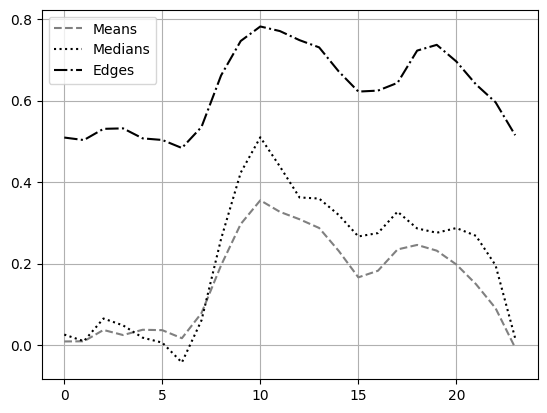

In [7]:
plt.plot(means, "--", color="gray", label="Means")
plt.plot(medians, ":", color="black", label="Medians")
plt.plot(edges, "-.", color="black", label="Edges")
plt.grid()
plt.legend()
plt.show()
# frequency = 20

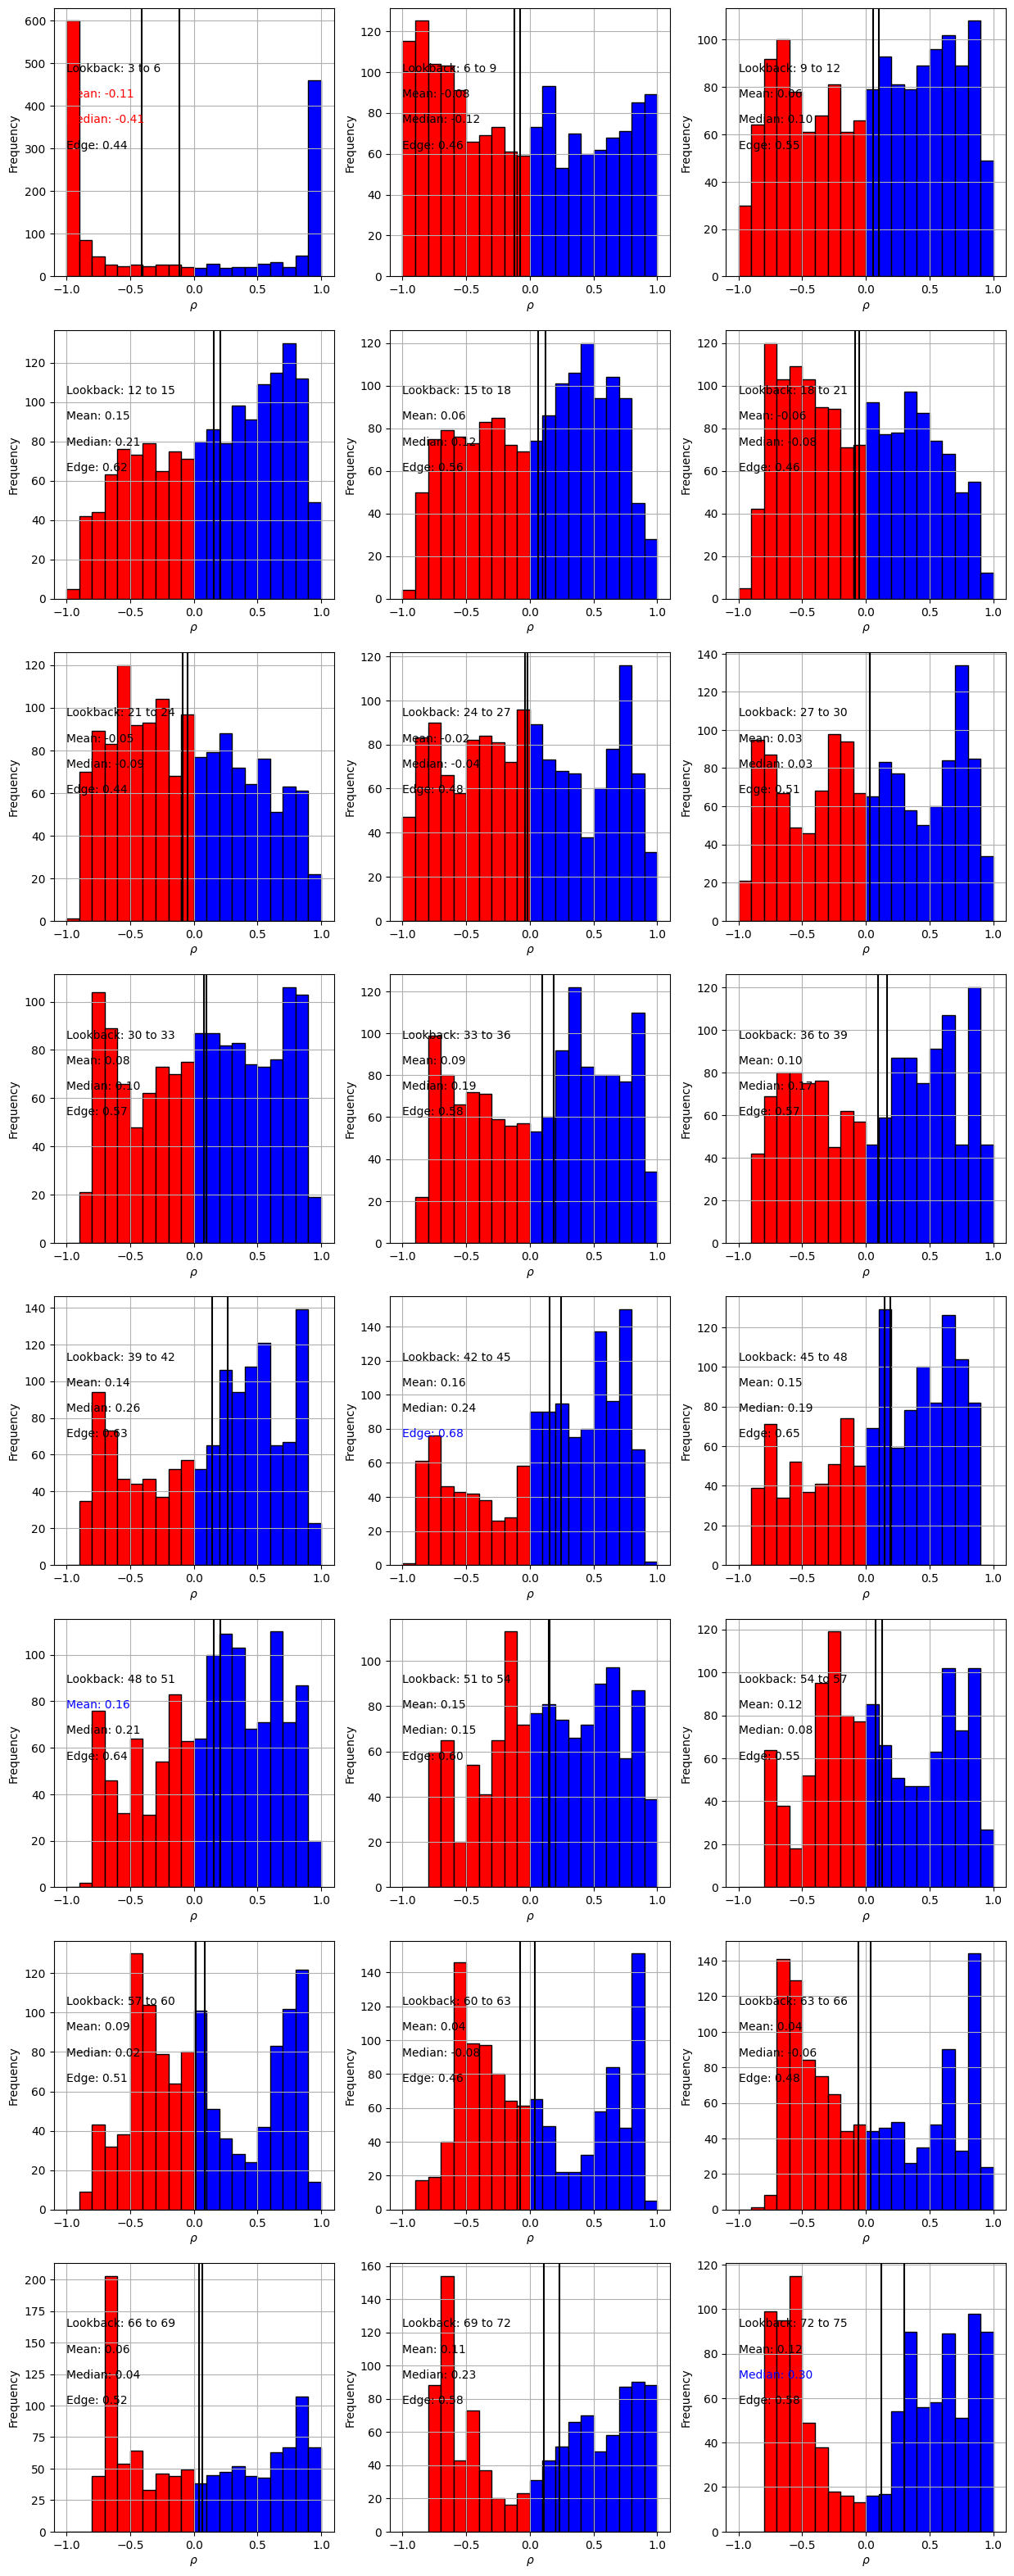

In [8]:
fig, axes = plt.subplots(8, 3, figsize=(15, 40))
medians = [np.median(CDS[k]) for k in CDS]
means = [np.mean(CDS[k]) for k in CDS]
edges = [(np.array(CDS[k]) > 0).sum() / len(CDS[k]) for k in CDS]
edge_min, edge_max = np.max(edges), np.max(edges)
median_min, median_max = np.min(medians), np.max(medians)
mean_min, mean_max = np.min(means), np.max(means)
for i in range(8):
    for j in range(3):
        k = i * 3 + j + 1
        # bins = np.linspace(0, min(10, np.max(C[k])), 11)
        bins = np.linspace(-1, 1, 21)
        x, y, z = axes[i][j].hist(CDS[k], bins=bins, edgecolor="black")
        for l in range(len(z)):
            if l < len(z) // 2:
                z[l].set_facecolor("r")
            else:
                z[l].set_facecolor("b")

        c_mean = (
            "b"
            if means[k - 1] == mean_max
            else ("r" if means[k - 1] == mean_min else "k")
        )
        c_median = (
            "b"
            if medians[k - 1] == median_max
            else ("r" if medians[k - 1] == median_min else "k")
        )
        c_edge = (
            "b"
            if edges[k - 1] == edge_max
            else ("r" if edges[k - 1] == edge_min else "k")
        )

        axes[i][j].axvline(np.median(CDS[k]), color="k")
        axes[i][j].axvline(np.mean(CDS[k]), color="k")
        axes[i][j].text(bins[0], 0.8 * x.max(), f"Lookback: {3 * k} to {3 * (k + 1)}")
        axes[i][j].text(
            bins[0], 0.5 * x.max(), f"Edge: {edges[k - 1]:.2f}", color=c_edge
        )
        axes[i][j].text(
            bins[0], 0.7 * x.max(), f"Mean: {means[k - 1]:.2f}", color=c_mean
        )
        axes[i][j].text(
            bins[0], 0.6 * x.max(), f"Median: {medians[k - 1]:.2f}", color=c_median
        )
        axes[i][j].set_xticks(bins[::5])
        axes[i][j].set_ylabel("Frequency")
        # axes[i][j].set_xlabel("$P\ (\%)$")
        # axes[i][j].set_xscale("log")
        axes[i][j].set_xlabel("$\\rho$")
        axes[i][j].grid()
plt.show()

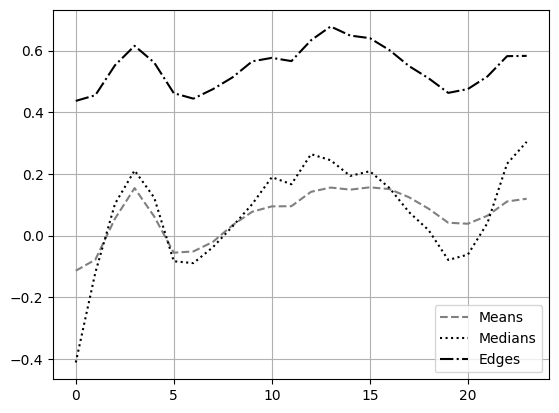

In [9]:
plt.plot(means, "--", color="gray", label="Means")
plt.plot(medians, ":", color="black", label="Medians")
plt.plot(edges, "-.", color="black", label="Edges")
plt.grid()
plt.legend()
plt.show()

<>:50: SyntaxWarning: invalid escape sequence '\ '
<>:50: SyntaxWarning: invalid escape sequence '\ '
/var/folders/mq/f_2xhb9d4xv13xb4888zcc_80000gn/T/ipykernel_4495/1403277062.py:50: SyntaxWarning: invalid escape sequence '\ '
  axes[i][j].set_xlabel("$P\ (\%)$")


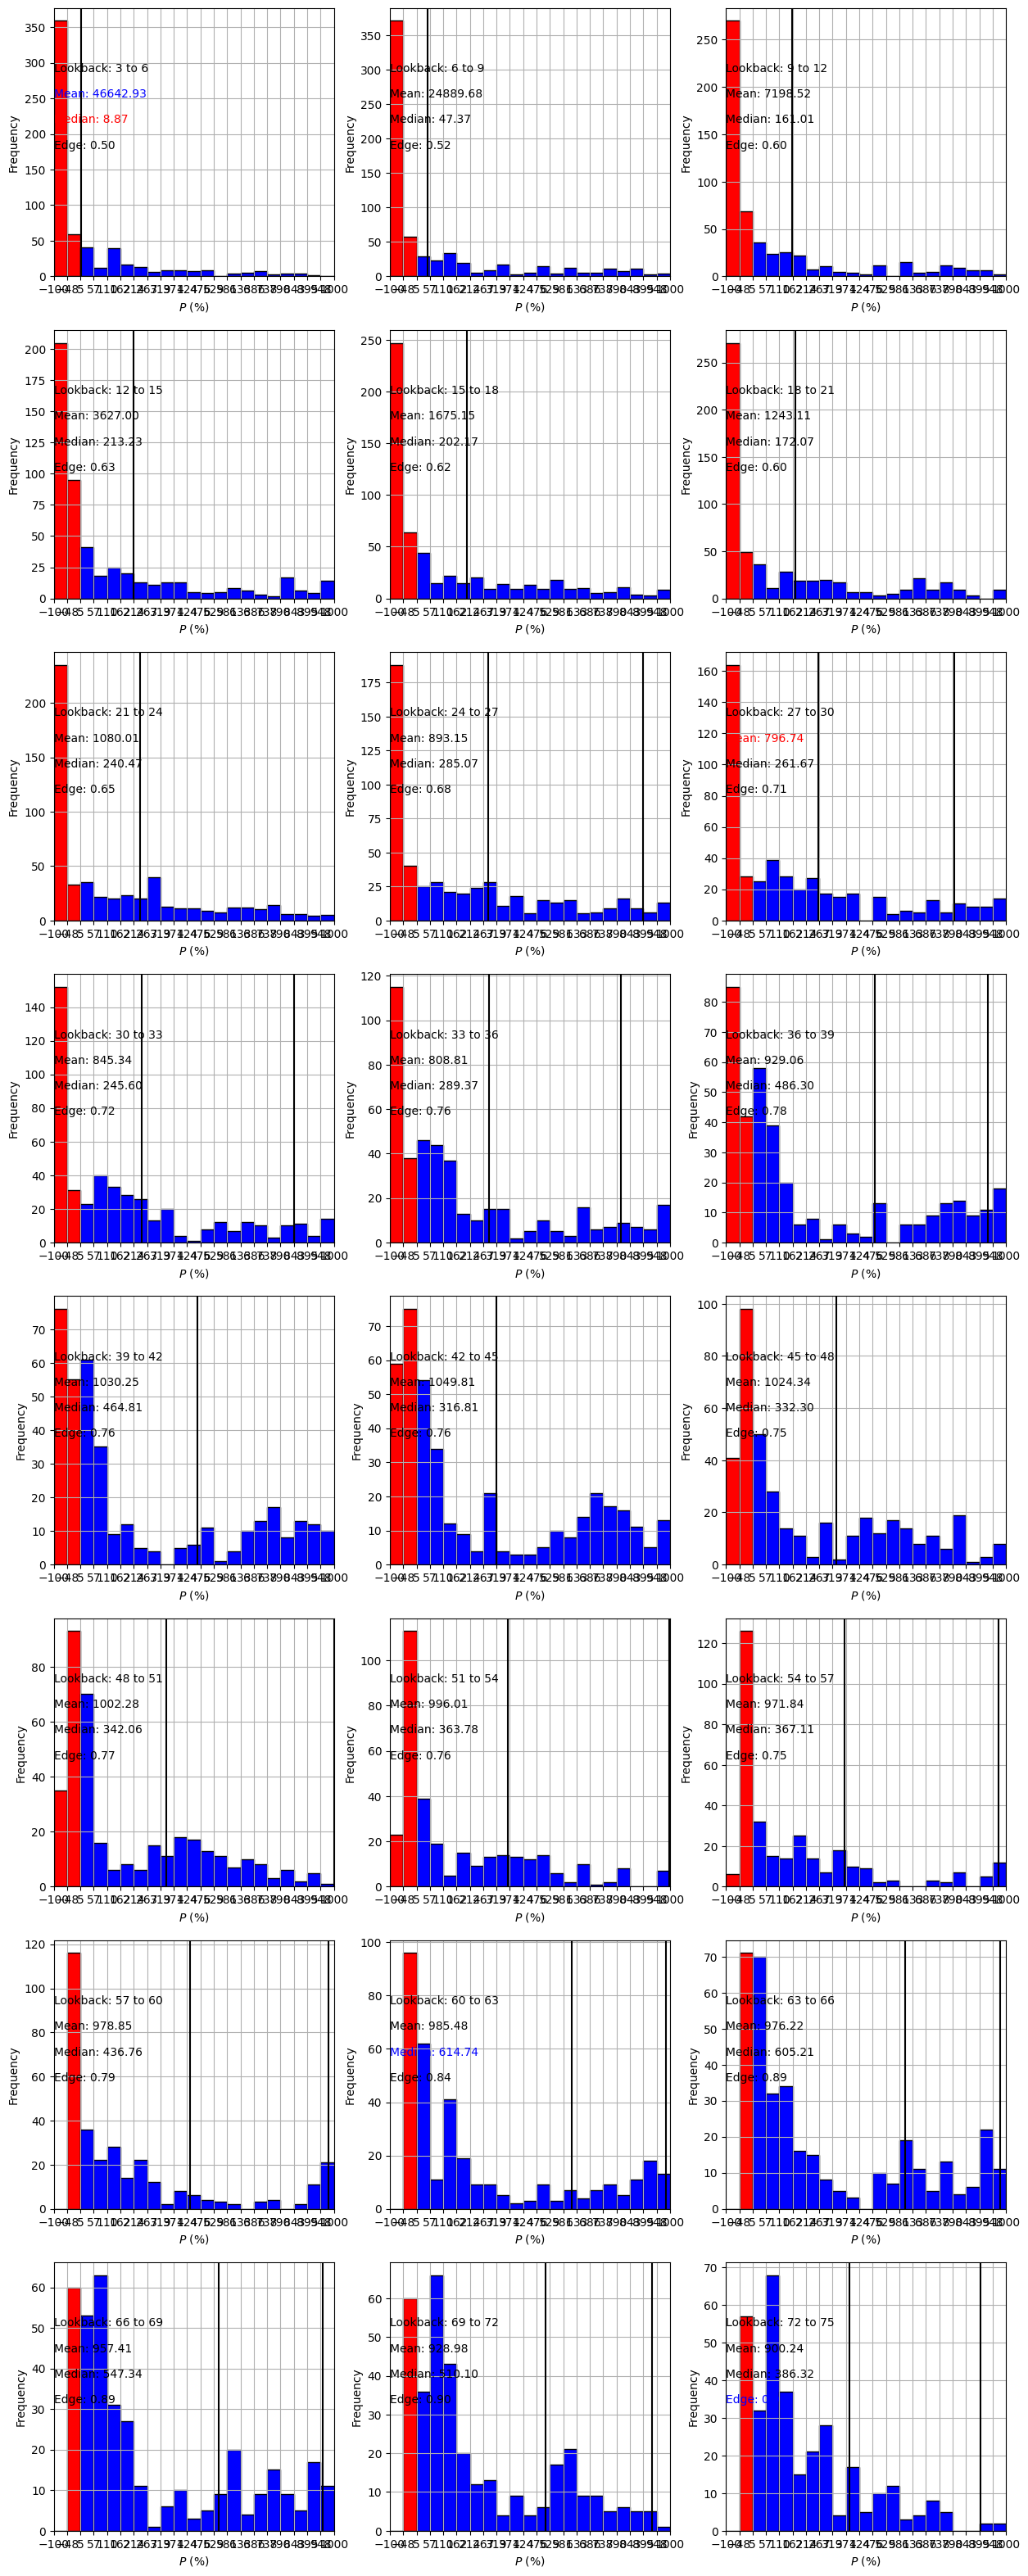

In [10]:
fig, axes = plt.subplots(8, 3, figsize=(15, 40))
medians = [np.median(PDS[k]) for k in PDS]
means = [np.mean(PDS[k]) for k in CSD]
edges = [(np.array(PDS[k]) > 0).sum() / len(PDS[k]) for k in PDS]
edge_min, edge_max = np.max(edges), np.max(edges)
median_min, median_max = np.min(medians), np.max(medians)
mean_min, mean_max = np.min(means), np.max(means)
for i in range(8):
    for j in range(3):
        k = i * 3 + j + 1
        bins = np.linspace(-100, 1000, 22)
        # bins = np.linspace(-1, 1, 21)
        x, y, z = axes[i][j].hist(PDS[k], bins=bins, edgecolor="black")
        for l in range(len(z)):
            if bins[l] < 0:
                z[l].set_facecolor("r")
            else:
                z[l].set_facecolor("b")

        c_mean = (
            "b"
            if means[k - 1] == mean_max
            else ("r" if means[k - 1] == mean_min else "k")
        )
        c_median = (
            "b"
            if medians[k - 1] == median_max
            else ("r" if medians[k - 1] == median_min else "k")
        )
        c_edge = (
            "b"
            if edges[k - 1] == edge_max
            else ("r" if edges[k - 1] == edge_min else "k")
        )

        axes[i][j].axvline(np.median(PDS[k]), color="k")
        axes[i][j].axvline(np.mean(PDS[k]), color="k")
        axes[i][j].text(bins[0], 0.8 * x.max(), f"Lookback: {3 * k} to {3 * (k + 1)}")
        axes[i][j].text(
            bins[0], 0.5 * x.max(), f"Edge: {edges[k - 1]:.2f}", color=c_edge
        )
        axes[i][j].text(
            bins[0], 0.7 * x.max(), f"Mean: {means[k - 1]:.2f}", color=c_mean
        )
        axes[i][j].text(
            bins[0], 0.6 * x.max(), f"Median: {medians[k - 1]:.2f}", color=c_median
        )
        axes[i][j].set_xticks(bins)
        axes[i][j].set_ylabel("Frequency")
        axes[i][j].set_xlabel("$P\ (\%)$")
        # axes[i][j].set_xlabel("$\rho$")
        # axes[i][j].set_xscale("log")
        axes[i][j].set_xlim(-100, 1000)
        axes[i][j].grid()
plt.show()

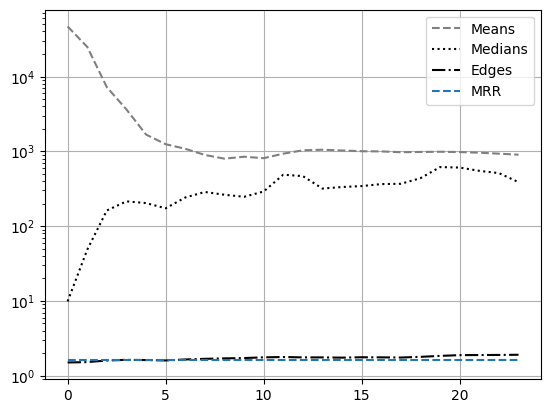

In [11]:
plt.plot(1 + np.array(means), "--", color="gray", label="Means")
plt.plot(1 + np.array(medians), ":", color="black", label="Medians")
plt.plot(1 + np.array(edges), "-.", color="black", label="Edges")
plt.plot(1.04**12 * np.ones(len(edges)), "--", label="MRR")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()

<>:50: SyntaxWarning: invalid escape sequence '\ '
<>:50: SyntaxWarning: invalid escape sequence '\ '
/var/folders/mq/f_2xhb9d4xv13xb4888zcc_80000gn/T/ipykernel_4495/502332185.py:50: SyntaxWarning: invalid escape sequence '\ '
  axes[i][j].set_xlabel("$P\ (\%)$")


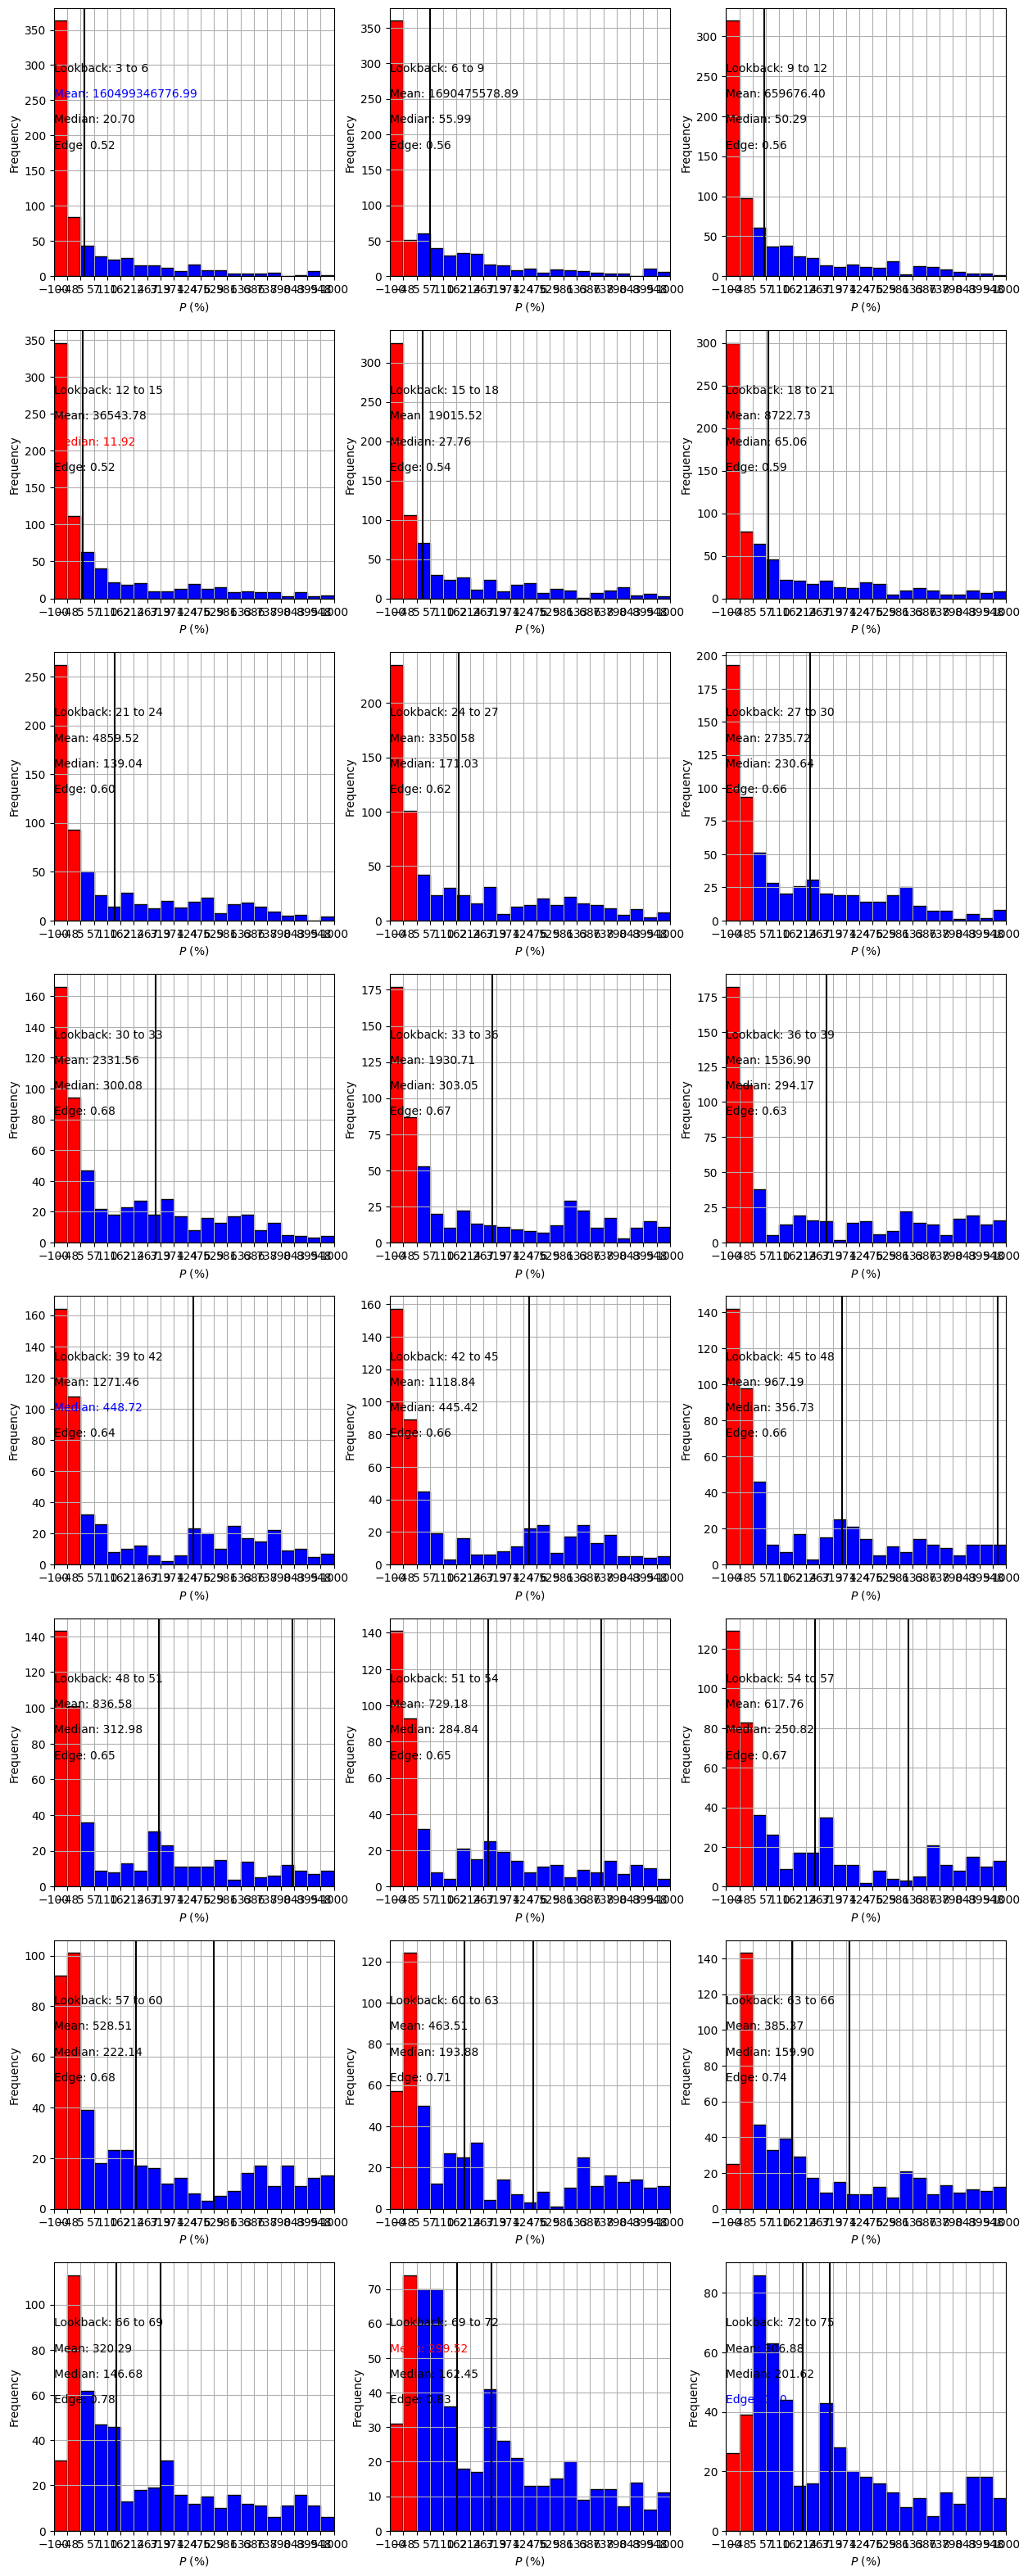

In [12]:
fig, axes = plt.subplots(8, 3, figsize=(15, 40))
medians = [np.median(PSD[k]) for k in PSD]
means = [np.mean(PSD[k]) for k in PSD]
edges = [(np.array(PSD[k]) > 0).sum() / len(PSD[k]) for k in PSD]
edge_min, edge_max = np.max(edges), np.max(edges)
median_min, median_max = np.min(medians), np.max(medians)
mean_min, mean_max = np.min(means), np.max(means)
for i in range(8):
    for j in range(3):
        k = i * 3 + j + 1
        bins = np.linspace(-100, 1000, 22)
        # bins = np.linspace(-1, 1, 21)
        x, y, z = axes[i][j].hist(PSD[k], bins=bins, edgecolor="black")
        for l in range(len(z)):
            if bins[l] < 0:
                z[l].set_facecolor("r")
            else:
                z[l].set_facecolor("b")

        c_mean = (
            "b"
            if means[k - 1] == mean_max
            else ("r" if means[k - 1] == mean_min else "k")
        )
        c_median = (
            "b"
            if medians[k - 1] == median_max
            else ("r" if medians[k - 1] == median_min else "k")
        )
        c_edge = (
            "b"
            if edges[k - 1] == edge_max
            else ("r" if edges[k - 1] == edge_min else "k")
        )

        axes[i][j].axvline(np.median(PSD[k]), color="k")
        axes[i][j].axvline(np.mean(PSD[k]), color="k")
        axes[i][j].text(bins[0], 0.8 * x.max(), f"Lookback: {3 * k} to {3 * (k + 1)}")
        axes[i][j].text(
            bins[0], 0.5 * x.max(), f"Edge: {edges[k - 1]:.2f}", color=c_edge
        )
        axes[i][j].text(
            bins[0], 0.7 * x.max(), f"Mean: {means[k - 1]:.2f}", color=c_mean
        )
        axes[i][j].text(
            bins[0], 0.6 * x.max(), f"Median: {medians[k - 1]:.2f}", color=c_median
        )
        axes[i][j].set_xticks(bins)
        axes[i][j].set_ylabel("Frequency")
        axes[i][j].set_xlabel("$P\ (\%)$")
        # axes[i][j].set_xlabel("$\rho$")
        # axes[i][j].set_xlim(0, max(10, np.max(PSD[k])))
        axes[i][j].set_xlim(-100, 1000)
        axes[i][j].grid()
plt.show()

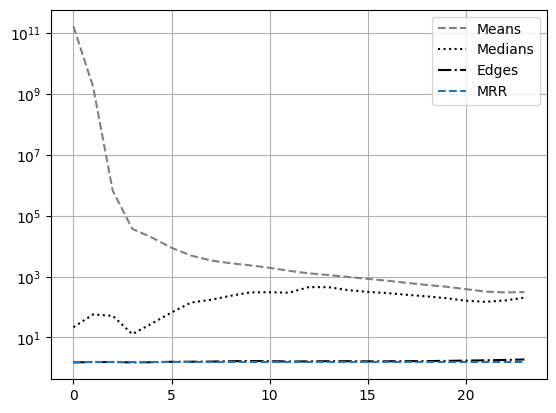

In [13]:
plt.plot(1 + np.array(means), "--", color="gray", label="Means")
plt.plot(1 + np.array(medians), ":", color="black", label="Medians")
plt.plot(1 + np.array(edges), "-.", color="black", label="Edges")
plt.plot(1.035**12 * np.ones(len(edges)), "--", label="MRR")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()